# Day 07: OpenCV ile Temel Görüntü İşleme Araç Seti

> **Aşama:** Faz 2: Endüstriyel Görüntü İşleme (Başlangıç)  
> **Konu:** imread, shape, dtype, BGR/RGB, Letterbox Resizing, Filtreler, Algısal CLAHE ve Sayısal Görüntü Analitiği  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Tarih:** 2026-09-04  
> **Lisans:** Özel Lisans — Tüm Hakları Saklıdır (c) 2026 Seydi Eryılmaz  

---

## 1. Problem Tanımı: Halı Üretiminde Optik Denetim, Sensör Gürültüsü ve Aydınlatma Dengesizlikleri

Merinos fabrikasyon ortamında dokuma tezgâhlarından çıkan salon halıları optik tarayıcılar ve yüksek hızlı endüstriyel kameralarla denetlenir. Ancak endüstriyel gerçeklikte:
1. **Sensör Gürültüsü ve İplik Tozları:** Statik elektrik ve hav uçuşmaları kamera lensinde ve halı yüzeyinde tuz-biber (impulse) gürültüsü oluşturur.
2. **Aydınlatma Dalgalanmaları:** Geniş halı eninde ($4\text{ metre}$) tavan aydınlatması homojen değildir; kenarlar gölgede kalırken merkez parlar.
3. **Geometrik Bozulmalar:** Halı ebatları farklıdır ($80\times 150\text{ cm}$ yolluk vs $200\times 290\text{ cm}$ salon halısı). Basit yeniden boyutlandırma dairesel madalyonları ve bordürleri elipsleştirerek model doğruluğunu yıkar.
4. **Kromatik Bozulma:** Renkli görüntülerde doğrudan RGB kanallarına uygulanan histogram eşitleme sahte renk tonlarına ve kromatizasyon sapmasına neden olur.

Bu laboratuvarda, bu 4 temel sorunu çözen endüstriyel kalitede bir görüntü işleme ve analitik araç kiti geliştireceğiz.

## 2. Neden Önemli? (Endüstriyel Kamera Kusurları & Model Ön İşleme Darboğazları)

Bir derin öğrenme modelinin (YOLO, ResNet, ViT) başarısı doğrudan girdi verisinin kalitesine bağlıdır:
- Eğer gürültü temizlenmezse, optik tozlar dokuma hatası (defekt) olarak yanlış sınıflandırılır (False Positive).
- Eğer en-boy oranı korunmazsa, model farklı ebatlardaki aynı deseni iki farklı desen olarak algılar.
- Eğer histogram eşitleme CIELAB $L^*$ kanalı yerine RGB kanallarına uygulanırsa, Merinos'un kurumsal bordo ve altın sarısı renkleri mora veya yeşile kayar.
- Windows dosya yollarındaki Türkçe karakterler (`Merinos 40 Günlük Staj Deneyimim`) standart `cv2.imread`'in sessizce `None` dönmesine ve üretim hattının kilitlenmesine yol açar.

## 3. Matematiksel & Algoritmik Temeller

### 1. Bilateral Filtre (Kenar Koruyucu Yumuşatma)
Standart Gauss filtresi yalnızca uzamsal yakınlığa ($g_s$) bakar; bu nedenle kenarları da bulanıklaştırır. Bilateral filtre ise hem piksel mesafesini ($g_s$) hem de radyometrik renk yoğunluğu farkını ($f_r$) çarpar:
$$I^{\text{filtered}}(x) = \frac{1}{W_p} \sum_{x_i \in \Omega} I(x_i) g_s(\|x_i - x\|) f_r(|I(x_i) - I(x)|)$$
Böylece aynı renk tonundaki iplik dalgalanmaları pürüzsüzleşirken, desen sınırları ve bordür çizgileri jilet gibi keskin kalır.

### 2. Algısal CLAHE (Contrast Limited Adaptive Histogram Equalization)
$$s_k = T(r_k) = \sum_{j=0}^k \frac{n_j}{N}$$
CLAHE, görüntüyü $8\times 8$ yerel bloklara böler, yerel histogramları çıkarır ve gürültü patlamasını önlemek için frekans eşiğini (*clip limit*) aşan pikselleri tüm aralığa eşit dağıtır. Renkli görüntülerde bu işlem yalnızca **CIELAB $L^*$** veya **YCrCb $Y$** parlaklık kanalına uygulanır.

### 3. Shannon Entropisi (Görüntü Bilgi Yoğunluğu)
$$H = -\sum_{i=0}^{255} p(i) \log_2 p(i)$$
Görüntüdeki desen karmaşıklığını ve bilgi zenginliğini ölçer. Düşük kontrastlı görüntülerde entropi düşüktür.

## 4. Kütüphane & Donanım İncelemesi

| Kütüphane | Hız / SIMD | Renk Uzayları | Bellek Modeli | Endüstriyel Uygunluk |
| :--- | :--- | :--- | :--- | :--- |
| **OpenCV (C++ Backend)** | ⚡ Çok Yüksek (IPP, AVX2) | BGR, RGB, HSV, LAB, YCrCb | NumPy ndarray (Sıfır kopya) | **Altın Standart (Production)** |
| **Pillow (PIL)** | 🐢 Orta | RGB, L, CMYK | PIL.Image (Dönüşüm ek yükü) | Prototipleme |
| **scikit-image** | ⚖️ İyi | Kapsamlı bilimsel | NumPy float64 (Bellek yoğun) | Akademik Araştırma |
| **Torchvision** | ⚡ Yüksek (GPU odaklı) | RGB, Gray | PyTorch Tensor | Derin Öğrenme Eğitimi |

## 5. Minimal Çalışır Kod: Unicode Uyumlu Güvenli Okuma ve BGR -> RGB Dönüşümü

In [1]:
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Day 07 mini_project modüllerini dinamik ve güvenli içeri aktarma
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day07" else CURRENT_DIR
DAY07_DIR = PROJECT_ROOT / "day07"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day07.mini_project.src.io_validator import ImageIOValidator
from day07.mini_project.src.color_spaces import ColorSpaceConverter
from day07.mini_project.src.resizer import AspectPreservingResizer
from day07.mini_project.src.filters import IndustrialFilterPipeline
from day07.mini_project.src.equalization import HistogramEqualizer
from day07.mini_project.src.analytics import ImageAnalyticsEngine

# Sentetik fikstür yolunu güvenli belirleme
fixtures_dir = DAY07_DIR / "mini_project" / "fixtures" / "synthetic_carpets"
if not fixtures_dir.exists():
    fixtures_dir = Path("day07/mini_project/fixtures/synthetic_carpets")

normal_img_path = fixtures_dir / "carpet_normal.png"

# Unicode-safe okuma
bgr_img = ImageIOValidator.read_image(normal_img_path)
meta = ImageIOValidator.extract_metadata(bgr_img, normal_img_path)

print(f"Başarıyla Yüklendi: {normal_img_path.name}")
print(f"Boyut: {meta.height}x{meta.width}, Kanal: {meta.channels}, Tip: {meta.dtype}, En-Boy: {meta.aspect_ratio}")
print(f"Bellek: {meta.size_bytes / 1024:.1f} KB, C-Contiguous: {meta.is_c_contiguous}")


Başarıyla Yüklendi: carpet_normal.png
Boyut: 360x480, Kanal: 3, Tip: uint8, En-Boy: 1.3333
Bellek: 506.2 KB, C-Contiguous: True


## 6. Deney 1: Renk Uzayları (BGR, RGB, HSV, CIELAB, YCrCb) ve Kanal Ayrıştırma

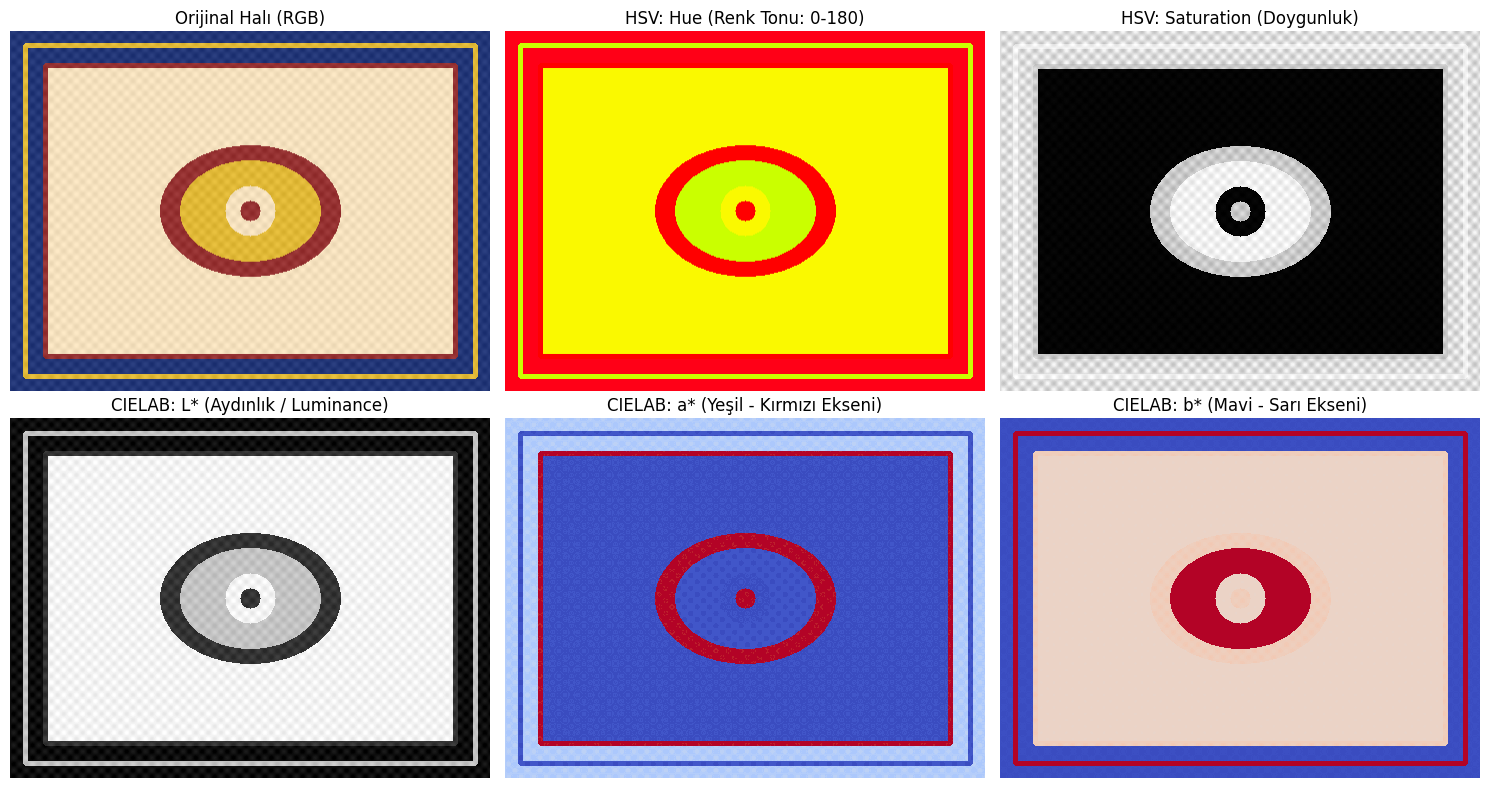

HSV Kanal İstatistikleri: {'H': {'mean': 40.94, 'std': 41.58, 'min': 0.0, 'max': 113.0}, 'S': {'mean': 111.02, 'std': 62.16, 'min': 55.0, 'max': 202.0}, 'V': {'mean': 203.61, 'std': 54.9, 'min': 110.0, 'max': 254.0}}


In [2]:
# BGR -> RGB
rgb_img = ColorSpaceConverter.convert(bgr_img, 'BGR', 'RGB')

# BGR -> HSV (Tekstil boya ve renk tonu analizi)
hsv_img = ColorSpaceConverter.convert(bgr_img, 'BGR', 'HSV')
hsv_channels = ColorSpaceConverter.split_channels(hsv_img, 'HSV')

# BGR -> CIELAB (İnsan gözü algısal renk uzayı)
lab_img = ColorSpaceConverter.convert(bgr_img, 'BGR', 'LAB')
lab_channels = ColorSpaceConverter.split_channels(lab_img, 'LAB')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(rgb_img)
axes[0, 0].set_title('Orijinal Halı (RGB)')
axes[0, 1].imshow(hsv_channels['H'], cmap='hsv')
axes[0, 1].set_title('HSV: Hue (Renk Tonu: 0-180)')
axes[0, 2].imshow(hsv_channels['S'], cmap='gray')
axes[0, 2].set_title('HSV: Saturation (Doygunluk)')

axes[1, 0].imshow(lab_channels['L'], cmap='gray')
axes[1, 0].set_title('CIELAB: L* (Aydınlık / Luminance)')
axes[1, 1].imshow(lab_channels['A'], cmap='coolwarm')
axes[1, 1].set_title('CIELAB: a* (Yeşil - Kırmızı Ekseni)')
axes[1, 2].imshow(lab_channels['B'], cmap='coolwarm')
axes[1, 2].set_title('CIELAB: b* (Mavi - Sarı Ekseni)')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

print('HSV Kanal İstatistikleri:', ColorSpaceConverter.channel_statistics(hsv_img, 'HSV'))


## 7. Deney 2: En-Boy Oranını Koruyan Letterbox Resizing ve Enterpolasyon

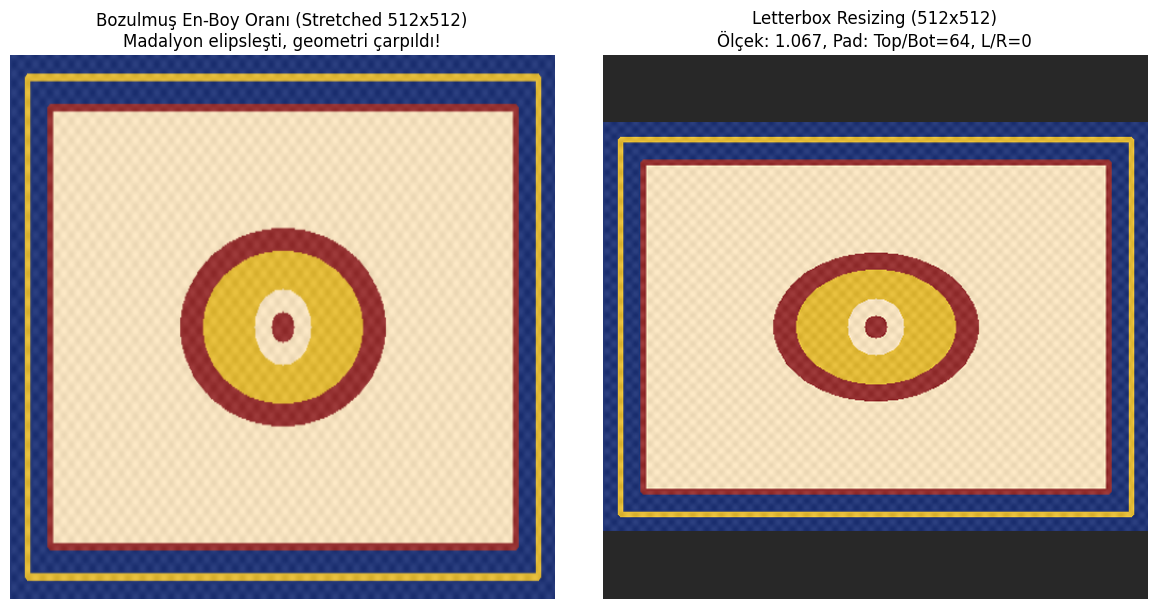

In [3]:
# En-boy oranını bozarak zorla boyutlandırma (Anti-Pattern)
stretched = AspectPreservingResizer.stretch_resize(bgr_img, (512, 512))

# Letterbox ile simetrik padding uygulayarak boyutlandırma (Best Practice)
letterbox_res = AspectPreservingResizer.letterbox(bgr_img, (512, 512), pad_color=(40, 40, 40))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(ColorSpaceConverter.convert(stretched, 'BGR', 'RGB'))
axes[0].set_title('Bozulmuş En-Boy Oranı (Stretched 512x512)\nMadalyon elipsleşti, geometri çarpıldı!')
axes[0].axis('off')

axes[1].imshow(ColorSpaceConverter.convert(letterbox_res.image, 'BGR', 'RGB'))
axes[1].set_title(f'Letterbox Resizing (512x512)\nÖlçek: {letterbox_res.scale:.3f}, Pad: Top/Bot={letterbox_res.pad_top}, L/R={letterbox_res.pad_left}')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 8. Deney 3: Mekânsal ve Kenar Koruyucu Filtreleme (Gaussian, Median, Bilateral, Unsharp Masking)

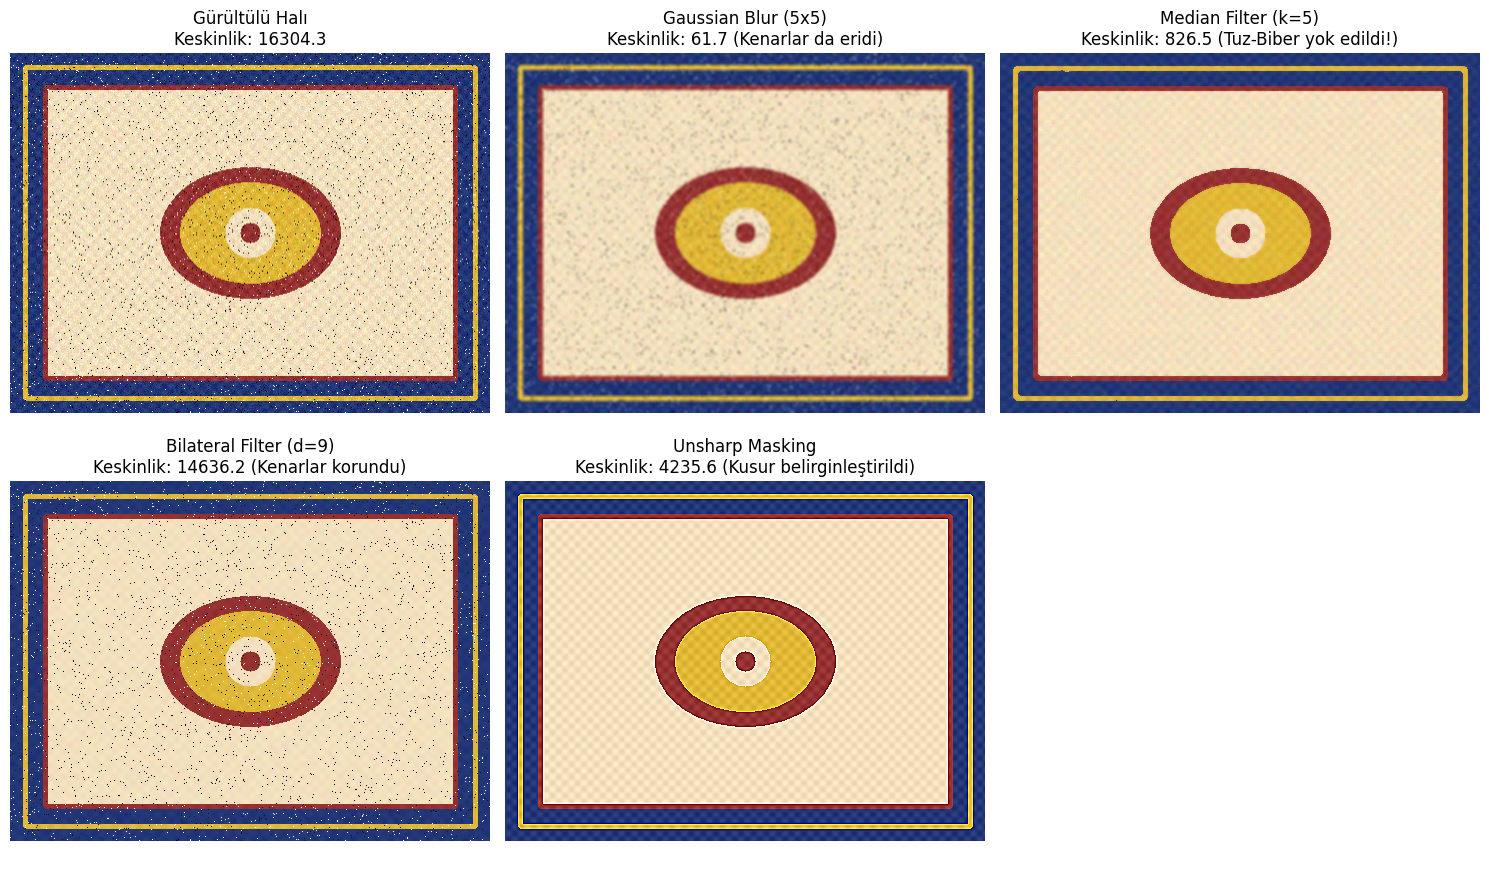

In [4]:
# Fikstür dizinini güvenli çözümle
if "fixtures_dir" not in locals():
    CURRENT_DIR = Path.cwd().resolve()
    PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day07" else CURRENT_DIR
    DAY07_DIR = PROJECT_ROOT / "day07"
    fixtures_dir = DAY07_DIR / "mini_project" / "fixtures" / "synthetic_carpets"
    if not fixtures_dir.exists():
        fixtures_dir = Path("day07/mini_project/fixtures/synthetic_carpets")

noisy_img = ImageIOValidator.read_image(fixtures_dir / 'carpet_noisy.png')

# Filtreleri uygulama
gauss = IndustrialFilterPipeline.gaussian_filter(noisy_img, (5, 5), sigma_x=1.5)
median = IndustrialFilterPipeline.median_filter(noisy_img, ksize=5)
bilateral = IndustrialFilterPipeline.bilateral_filter(noisy_img, d=9, sigma_color=75, sigma_space=75)
unsharp = IndustrialFilterPipeline.unsharp_mask(bgr_img, strength=1.5)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0, 0].imshow(ColorSpaceConverter.convert(noisy_img, 'BGR', 'RGB'))
axes[0, 0].set_title(f'Gürültülü Halı\nKeskinlik: {IndustrialFilterPipeline.calculate_sharpness(noisy_img):.1f}')

axes[0, 1].imshow(ColorSpaceConverter.convert(gauss, 'BGR', 'RGB'))
axes[0, 1].set_title(f'Gaussian Blur (5x5)\nKeskinlik: {IndustrialFilterPipeline.calculate_sharpness(gauss):.1f} (Kenarlar da eridi)')

axes[0, 2].imshow(ColorSpaceConverter.convert(median, 'BGR', 'RGB'))
axes[0, 2].set_title(f'Median Filter (k=5)\nKeskinlik: {IndustrialFilterPipeline.calculate_sharpness(median):.1f} (Tuz-Biber yok edildi!)')

axes[1, 0].imshow(ColorSpaceConverter.convert(bilateral, 'BGR', 'RGB'))
axes[1, 0].set_title(f'Bilateral Filter (d=9)\nKeskinlik: {IndustrialFilterPipeline.calculate_sharpness(bilateral):.1f} (Kenarlar korundu)')

axes[1, 1].imshow(ColorSpaceConverter.convert(unsharp, 'BGR', 'RGB'))
axes[1, 1].set_title(f'Unsharp Masking\nKeskinlik: {IndustrialFilterPipeline.calculate_sharpness(unsharp):.1f} (Kusur belirginleştirildi)')

axes[1, 2].axis('off')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


## 9. Deney 4: Histogram Eşitleme ve Algısal CLAHE (Global HE vs CIELAB L* CLAHE)

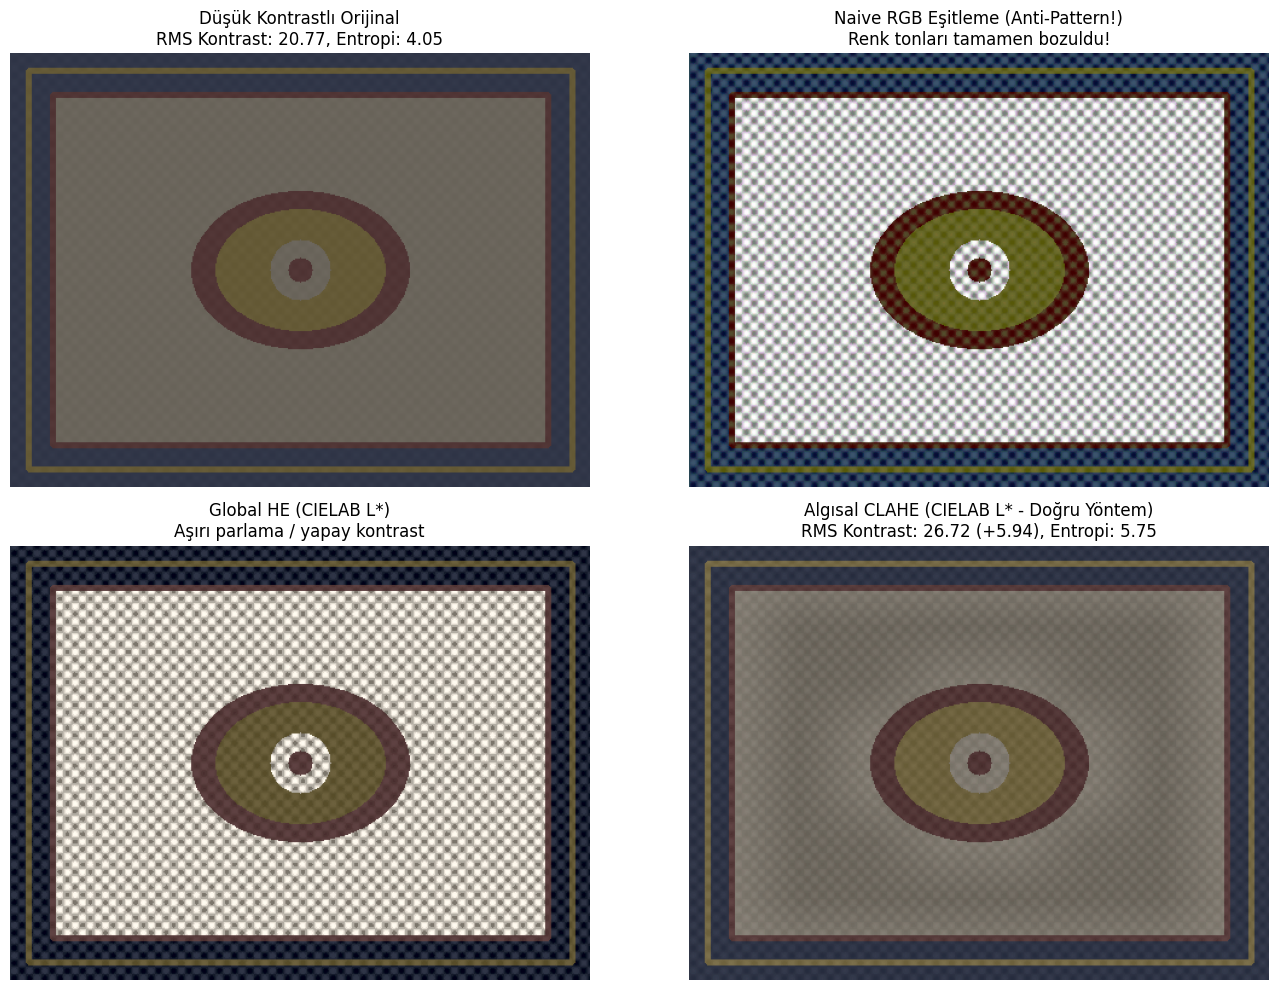

In [5]:
# Fikstür dizinini güvenli çözümle
if "fixtures_dir" not in locals():
    CURRENT_DIR = Path.cwd().resolve()
    PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day07" else CURRENT_DIR
    DAY07_DIR = PROJECT_ROOT / "day07"
    fixtures_dir = DAY07_DIR / "mini_project" / "fixtures" / "synthetic_carpets"
    if not fixtures_dir.exists():
        fixtures_dir = Path("day07/mini_project/fixtures/synthetic_carpets")

low_con_img = ImageIOValidator.read_image(fixtures_dir / 'carpet_low_contrast.png')

# 1. Naive RGB eşitliği (Anti-pattern: sahte renkler üretir)
naive_he = HistogramEqualizer.naive_rgb_equalize(low_con_img)

# 2. Global HE (CIELAB L*)
global_lab = HistogramEqualizer.enhance_color_perceptual(low_con_img, method='global', space='lab')

# 3. CLAHE (CIELAB L* - Endüstriyel Altın Standart)
clahe_lab = HistogramEqualizer.enhance_color_perceptual(low_con_img, method='clahe', space='lab', clip_limit=2.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(ColorSpaceConverter.convert(low_con_img, 'BGR', 'RGB'))
p_orig = ImageAnalyticsEngine.profile_image(low_con_img)
axes[0, 0].set_title(f'Düşük Kontrastlı Orijinal\nRMS Kontrast: {p_orig.rms_contrast:.2f}, Entropi: {p_orig.shannon_entropy:.2f}')

axes[0, 1].imshow(ColorSpaceConverter.convert(naive_he, 'BGR', 'RGB'))
p_naive = ImageAnalyticsEngine.profile_image(naive_he)
axes[0, 1].set_title(f'Naive RGB Eşitleme (Anti-Pattern!)\nRenk tonları tamamen bozuldu!')

axes[1, 0].imshow(ColorSpaceConverter.convert(global_lab, 'BGR', 'RGB'))
p_glab = ImageAnalyticsEngine.profile_image(global_lab)
axes[1, 0].set_title(f'Global HE (CIELAB L*)\nAşırı parlama / yapay kontrast')

axes[1, 1].imshow(ColorSpaceConverter.convert(clahe_lab, 'BGR', 'RGB'))
p_clahe = ImageAnalyticsEngine.profile_image(clahe_lab)
axes[1, 1].set_title(f'Algısal CLAHE (CIELAB L* - Doğru Yöntem)\nRMS Kontrast: {p_clahe.rms_contrast:.2f} (+{p_clahe.rms_contrast - p_orig.rms_contrast:.2f}), Entropi: {p_clahe.shannon_entropy:.2f}')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


## 4. Sentetik Halı Fikstürleri Üzerinde Karşılaştırmalı Görüntü İşleme Matrisi (Image Processing Comparison on Synthetic Carpet Images)

Let's compare different enhancement techniques on our synthetic carpet fixtures:
Normal, gürültülü (noisy) ve düşük kontrastlı (low contrast) sentetik halı kumaşları üzerinde **Gaussian Smoothing**, **Median Filtering**, **Bilateral Filtering** ve **Algısal CLAHE** tekniklerinin başa baş karşılaştırmalı 3x5 görsel teşhis matrisi:

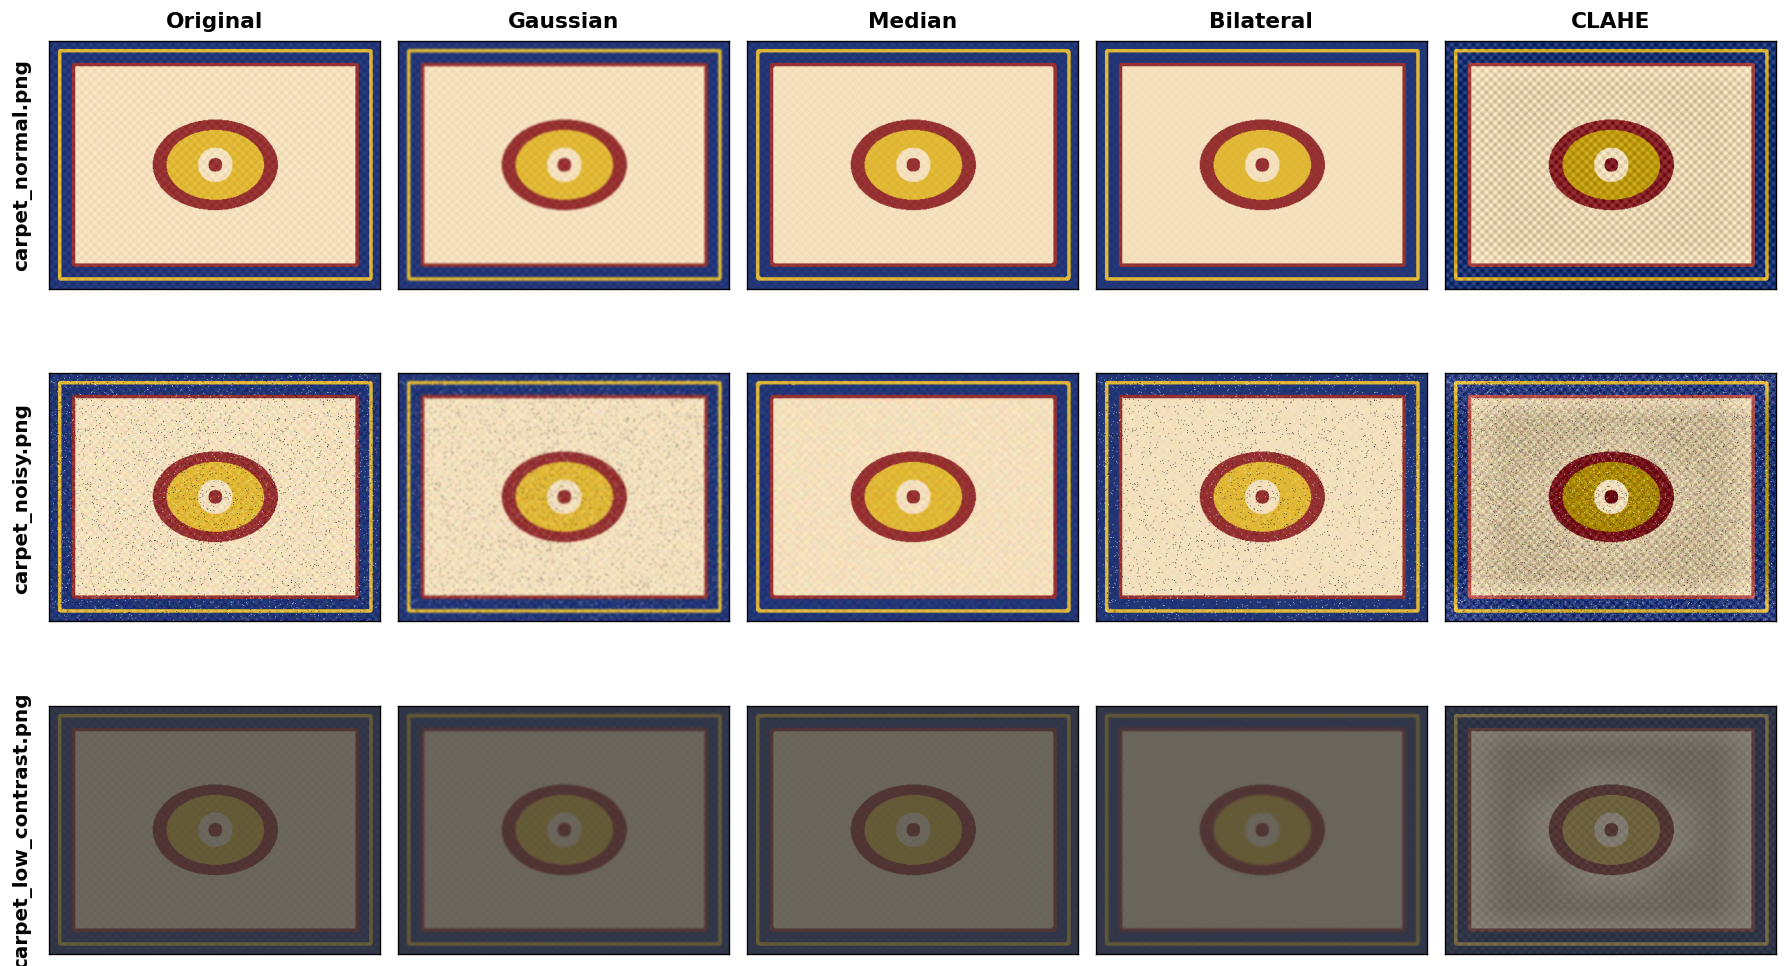

In [6]:
import sys
from pathlib import Path

# Proje kök dizinini sys.path'e dinamik ekle
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day07" else CURRENT_DIR
DAY07_DIR = PROJECT_ROOT / "day07"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import cv2
import numpy as np
import matplotlib.pyplot as plt

from day07.mini_project.src.io_validator import ImageIOValidator
from day07.mini_project.src.color_spaces import ColorSpaceConverter
from day07.mini_project.src.filters import IndustrialFilterPipeline
from day07.mini_project.src.equalization import HistogramEqualizer

def visualize_image_processing_comparison(save_path: str = None):
    """Process and display results for different test images in a 3x5 comparison grid."""
    fixtures_dir = DAY07_DIR / "mini_project" / "fixtures" / "synthetic_carpets"
    if not fixtures_dir.exists():
        fixtures_dir = Path("day07/mini_project/fixtures/synthetic_carpets")

    fixture_files = [
        ("carpet_normal.png", "carpet_normal.png"),
        ("carpet_noisy.png", "carpet_noisy.png"),
        ("carpet_low_contrast.png", "carpet_low_contrast.png")
    ]

    cols = ["Original", "Gaussian", "Median", "Bilateral", "CLAHE"]
    fig, axes = plt.subplots(3, 5, figsize=(15, 9), dpi=120)

    for row_idx, (fname, display_name) in enumerate(fixture_files):
        img_bgr = ImageIOValidator.read_image(fixtures_dir / fname)
        
        # 1. Original (RGB)
        orig_rgb = ColorSpaceConverter.convert(img_bgr, "BGR", "RGB")
        
        # 2. Gaussian Filter (5x5, sigma=1.5)
        gauss = IndustrialFilterPipeline.gaussian_filter(img_bgr, (5, 5), 1.5)
        gauss_rgb = ColorSpaceConverter.convert(gauss, "BGR", "RGB")
        
        # 3. Median Filter (k=5)
        med = IndustrialFilterPipeline.median_filter(img_bgr, 5)
        med_rgb = ColorSpaceConverter.convert(med, "BGR", "RGB")
        
        # 4. Bilateral Filter (d=9, sigma_color=75, sigma_space=75)
        bilat = IndustrialFilterPipeline.bilateral_filter(img_bgr, d=9, sigma_color=75.0, sigma_space=75.0)
        bilat_rgb = ColorSpaceConverter.convert(bilat, "BGR", "RGB")
        
        # 5. CLAHE (CIELAB L* perceptual)
        clahe = HistogramEqualizer.enhance_color_perceptual(img_bgr, method="clahe", space="lab")
        clahe_rgb = ColorSpaceConverter.convert(clahe, "BGR", "RGB")
        
        row_imgs = [orig_rgb, gauss_rgb, med_rgb, bilat_rgb, clahe_rgb]
        
        for col_idx, img in enumerate(row_imgs):
            ax = axes[row_idx, col_idx]
            ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])
            if row_idx == 0:
                ax.set_title(cols[col_idx], fontsize=13, fontweight="bold", pad=8)
            if col_idx == 0:
                ax.set_ylabel(display_name, fontsize=12, fontweight="bold", labelpad=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

# Process and display results for different test images
visualize_image_processing_comparison()


## 10. Mühendislik Çıkarımları, CLI Entegrasyonu ve Day 08'e Bağlantı

### Mühendislik Çıkarımları:
1. **Unicode Uyumlu G/Ç:** Windows dosya sisteminde Türkçe karakter içeren yollarda `cv2.imread` yerine ikili `np.fromfile` + `cv2.imdecode` yaklaşımı zorunludur.
2. **Renk Koruması:** Renkli tekstil görüntülerinde kontrast artırımı yapılırken doğrudan RGB kanallarına dokunulmamalı; işlem sadece CIELAB $L^*$ veya YCrCb $Y$ kanalına izole edilmelidir.
3. **Geometrik Bütünlük:** Kare derin öğrenme modellerine ($512\times 512$) veri beslerken en-boy oranını koruyan **Letterbox Resizing** kullanılmalıdır.
4. **Gürültü & Kenar Dengesi:** Optik toz lekeleri için **Median Filtre**, desen keskinliğini koruyarak ilmek dalgalanmasını pürüzsüzleştirmek için **Bilateral Filtre** en yüksek verimi sağlamaktadır.

### 🚀 Sıradaki Adım: Day 08
**Day 08: Algısal Renk Uzayı Analizi ve Renk Eşikleme:**
`day08: implement perceptual color space analysis — RGB, HSV, CIELAB dönüşümleri ve renk threshold testleri`